In [1]:
# Reproduction of Moore et al. (2020), Extended Data Figure 3b
#
# Paper:
# ENCODE Project Consortium. Expanded encyclopaedias of DNA elements
# in the human and mouse genomes. Nature 583, 699–710 (2020).
# DOI: 10.1038/s41586-020-2493-4
#
# Target result:
# Distribution of the percent of ENCODE TF ChIP-seq peaks overlapping
# the cell-type-agnostic human GRCh38 cCRE registry.
#
# Author-reported conclusion:
# Median TF ChIP-seq dataset: 90% of peaks overlap a cCRE.
#
# Uses the authors' Supplementary Table 18a results
# for the baseline figure reproduction.

In [2]:
!pip -q install pandas openpyxl matplotlib seaborn numpy requests

In [3]:

from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

OUTDIR = Path("encode_ccre_extended_data_fig_3b")
OUTDIR.mkdir(exist_ok=True)


plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

print(f"Outputs will be saved in: {OUTDIR.resolve()}")

Outputs will be saved in: /content/encode_ccre_extended_data_fig_3b


In [4]:

# Download the paper's supplementary data file

# The reproduction relies on the authors' own precomputed results rather than
# recomputing peak/cCRE overlaps from raw ENCODE data. Supplementary Table 18
# (hosted by the publisher, Nature/Springer) contains, per TF ChIP-seq
# experiment, the percentage of peaks that overlap a cCRE.


# Direct URL to the supplementary Excel workbook for this paper (DOI-based path
# on Springer's static content server). Split across two string literals only
# for readability/line length; Python concatenates adjacent string literals.

SUPP_URL = (
    "https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-020-2493-4/"
    "MediaObjects/41586_2020_2493_MOESM20_ESM.xlsx"
)

XLSX_PATH = OUTDIR / "41586_2020_2493_MOESM20_ESM.xlsx"

# Fetch the file over HTTP with a generous timeout (the file is small, but
# network conditions vary). raise_for_status() aborts the notebook early with
# a clear error if the download fails (e.g. 404/500) rather than silently
# writing an HTML error page to disk.
response = requests.get(SUPP_URL, timeout=120)
response.raise_for_status()
# Write the raw response bytes directly to disk (binary mode, since this is a
# zipped/binary .xlsx file, not text).
XLSX_PATH.write_bytes(response.content)

print(f"Downloaded: {XLSX_PATH.name}")
print(f"Size: {XLSX_PATH.stat().st_size:,} bytes")

Downloaded: 41586_2020_2493_MOESM20_ESM.xlsx
Size: 96,715 bytes


In [5]:

# The downloaded workbook contains multiple worksheets (a "Contents" cover
# sheet plus several data tables, 18a-18d). We open it once with
# pd.ExcelFile so we can list sheet names without loading all the data, then
# pick out the specific sheet needed for this reproduction (18a = TF ChIP-seq
# peak overlap with the human cCRE registry).
workbook = pd.ExcelFile(XLSX_PATH)

print("Available worksheets:")
for sheet in workbook.sheet_names:
    print(" -", sheet)

SHEET_18A = "Supplementary Table 18a"

if SHEET_18A not in workbook.sheet_names:
    raise ValueError(
        f"Expected worksheet '{SHEET_18A}' was not found.\n"
        f"Available worksheets: {workbook.sheet_names}"
    )

print(f"\nSelected worksheet: {SHEET_18A}")

Available worksheets:
 - Contents
 - Supplementary Table 18a
 - Supplementary Table 18b
 - Supplementary Table 18c
 - Supplementary Table 18d

Selected worksheet: Supplementary Table 18a


In [6]:

# Locate the header row and load the raw worksheet as a DataFrame

# Supplementary Excel sheets from papers often have a title/caption in the
# first row(s) before the actual column headers begin. Rather than hardcoding
# a row offset (fragile if the layout changes slightly), this helper scans
# the first `max_rows` rows for one that contains a known column-header
# substring ("Experiment accession") and returns its (0-based) row index.
def find_header_row(path, sheet_name, required_text="Experiment accession", max_rows=30):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None, nrows=max_rows)
# Read the top of the sheet with header=None so pandas doesn't try to
    # guess a header row itself; every row is treated as plain data.
    for i in range(len(raw)):
        row_text = " | ".join(
            raw.iloc[i].fillna("").astype(str).tolist()
        )
        if required_text.lower() in row_text.lower():
            return i

    print("Could not find the expected header. First 15 worksheet rows:")
    display(raw.head(15))
    raise ValueError(
        f"Could not find '{required_text}' in worksheet '{sheet_name}'."
    )

HEADER_ROW = find_header_row(XLSX_PATH, SHEET_18A)

print(f"Detected header row: {HEADER_ROW}")
# Re-read the sheet, this time telling pandas which row to use as the column
# header, so `raw_18a` has proper column names instead of positional 0..N.
raw_18a = pd.read_excel(
    XLSX_PATH,
    sheet_name=SHEET_18A,
    header=HEADER_ROW
)

display(raw_18a.head())

Detected header row: 1


,Experiment accession,Peak accession,Biosample,Target,# peaks,% overlap with cCREs
0,ENCSR000BPF,ENCFF353WKC,A549,TAF1,10949,0.996895
1,ENCSR000DMH,ENCFF281OWZ,lung,CTCF,22955,0.996820
2,ENCSR000DND,ENCFF547CLG,pancreas,CTCF,28049,0.995187
3,ENCSR000BHT,ENCFF557UKG,HeLa-S3,TAF1,14211,0.995145
4,ENCSR000EFC,ENCFF382EZV,IMR-90,CHD1,3260,0.995092


In [7]:

# The relevant columns are, in this order:
# Experiment accession
# Peak accession
# Biosample
# Target
# peaks
# overlap with cCREs
#
# The final overlap column is stored by the authors as a FRACTION:
# 0.996895 means 99.6895%.

# Keep only the first 6 columns (in case the sheet has extra trailing
# columns/notes) and work on a copy so we don't mutate `raw_18a`.

table18a = raw_18a.iloc[:, :6].copy()

table18a.columns = [
    "experiment_accession",
    "peak_accession",
    "biosample",
    "target",
    "n_peaks",
    "authors_overlap_fraction"
]

# Keep only real ENCODE experiment/file rows.
table18a["experiment_accession"] = (
    table18a["experiment_accession"]
    .astype(str)
    .str.strip()
)

table18a["peak_accession"] = (
    table18a["peak_accession"]
    .astype(str)
    .str.strip()
)

results = table18a[
    table18a["experiment_accession"].str.startswith("ENCSR", na=False)
    & table18a["peak_accession"].str.startswith("ENCFF", na=False)
].copy()

# Clean text columns.
results["biosample"] = results["biosample"].astype(str).str.strip()
results["target"] = results["target"].astype(str).str.strip()

# Clean peak totals.
results["n_peaks"] = pd.to_numeric(
    results["n_peaks"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# Clean the author overlap fractions.
results["authors_overlap_fraction"] = pd.to_numeric(
    results["authors_overlap_fraction"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip(),
    errors="coerce"
)

results = (
    results
    .dropna(subset=["n_peaks", "authors_overlap_fraction"])
    .drop_duplicates()
    .reset_index(drop=True)
)

# CORRECT UNIT CONVERSION:
# Convert 0–1 fractions to 0–100 percentages.
results["authors_percent_overlap"] = (
    100 * results["authors_overlap_fraction"]
)

# Validation checks.
assert results["authors_overlap_fraction"].between(0, 1).all(), (
    "The source overlap values should be fractions from 0 to 1. "
    "Do not multiply a second time if they are already percentages."
)

assert results["authors_percent_overlap"].between(0, 100).all(), (
    "Converted overlap values should be percentages from 0 to 100."
)

print(f"Loaded {len(results):,} TF ChIP-seq datasets.")
display(results.head(10))

Loaded 982 TF ChIP-seq datasets.


,experiment_accession,peak_accession,biosample,target,n_peaks,authors_overlap_fraction,authors_percent_overlap
0,ENCSR000BPF,ENCFF353WKC,A549,TAF1,10949,0.996895,99.6895
1,ENCSR000DMH,ENCFF281OWZ,lung,CTCF,22955,0.996820,99.6820
2,ENCSR000DND,ENCFF547CLG,pancreas,CTCF,28049,0.995187,99.5187
3,ENCSR000BHT,ENCFF557UKG,HeLa-S3,TAF1,14211,0.995145,99.5145
4,ENCSR000EFC,ENCFF382EZV,IMR-90,CHD1,3260,0.995092,99.5092
5,ENCSR481YWD,ENCFF497RWM,A549,SMC3,16639,0.995012,99.5012
6,ENCSR000DYC,ENCFF674RQX,A549,MYC,9031,0.994906,99.4906
7,ENCSR000AQC,ENCFF967SJM,H1-hESC,RBBP5,20067,0.994568,99.4568
8,ENCSR785OKZ,ENCFF347MAZ,GM12878,RB1,9993,0.993796,99.3796
9,ENCSR000DZP,ENCFF599ZQS,GM12878,SMC3,20134,0.993444,99.3444


In [8]:

# Compute summary statistics and compare against the paper's reported value

# The paper (main text / this Extended Data figure's caption) reports a
# median of 90% peak overlap with cCREs across TF ChIP-seq datasets. This
# constant is the "ground truth" target we're checking our reproduction
# against.
paper_reported_median = 90.0

median_overlap = results["authors_percent_overlap"].median()
mean_overlap = results["authors_percent_overlap"].mean()
minimum_overlap = results["authors_percent_overlap"].min()
maximum_overlap = results["authors_percent_overlap"].max()
below_70 = int((results["authors_percent_overlap"] < 70).sum())

summary = pd.DataFrame({
    "Metric": [
        "Number of ENCODE TF ChIP-seq datasets",
        "Median cCRE-overlapping peaks (%)",
        "Mean cCRE-overlapping peaks (%)",
        "Minimum overlap (%)",
        "Maximum overlap (%)",
        "Datasets below 70% overlap",
        "Paper-reported median (%)",
        "Difference from paper median (percentage points)"
    ],
    "Value": [
        len(results),
        round(median_overlap, 2),
        round(mean_overlap, 2),
        round(minimum_overlap, 2),
        round(maximum_overlap, 2),
        below_70,
        paper_reported_median,
        round(median_overlap - paper_reported_median, 2)
    ]
})

display(summary)

print("\nFirst five converted values:")
display(
    results[
        [
            "experiment_accession",
            "peak_accession",
            "target",
            "authors_overlap_fraction",
            "authors_percent_overlap"
        ]
    ].head()
)

assert abs(median_overlap - 90.0) < 1.0, (
    f"Median is {median_overlap:.2f}%, but it should be close to 90%. "
    "Confirm that authors_overlap_fraction was multiplied by 100 exactly once."
)

,Metric,Value
0,Number of ENCODE TF ChIP-seq datasets,982.00
1,Median cCRE-overlapping peaks (%),90.46
2,Mean cCRE-overlapping peaks (%),85.73
3,Minimum overlap (%),20.59
4,Maximum overlap (%),99.69
5,Datasets below 70% overlap,115.00
6,Paper-reported median (%),90.00
7,Difference from paper median (percentage points),0.46



First five converted values:


,experiment_accession,peak_accession,target,authors_overlap_fraction,authors_percent_overlap
0,ENCSR000BPF,ENCFF353WKC,TAF1,0.996895,99.6895
1,ENCSR000DMH,ENCFF281OWZ,CTCF,0.996820,99.6820
2,ENCSR000DND,ENCFF547CLG,CTCF,0.995187,99.5187
3,ENCSR000BHT,ENCFF557UKG,TAF1,0.995145,99.5145
4,ENCSR000EFC,ENCFF382EZV,CHD1,0.995092,99.5092


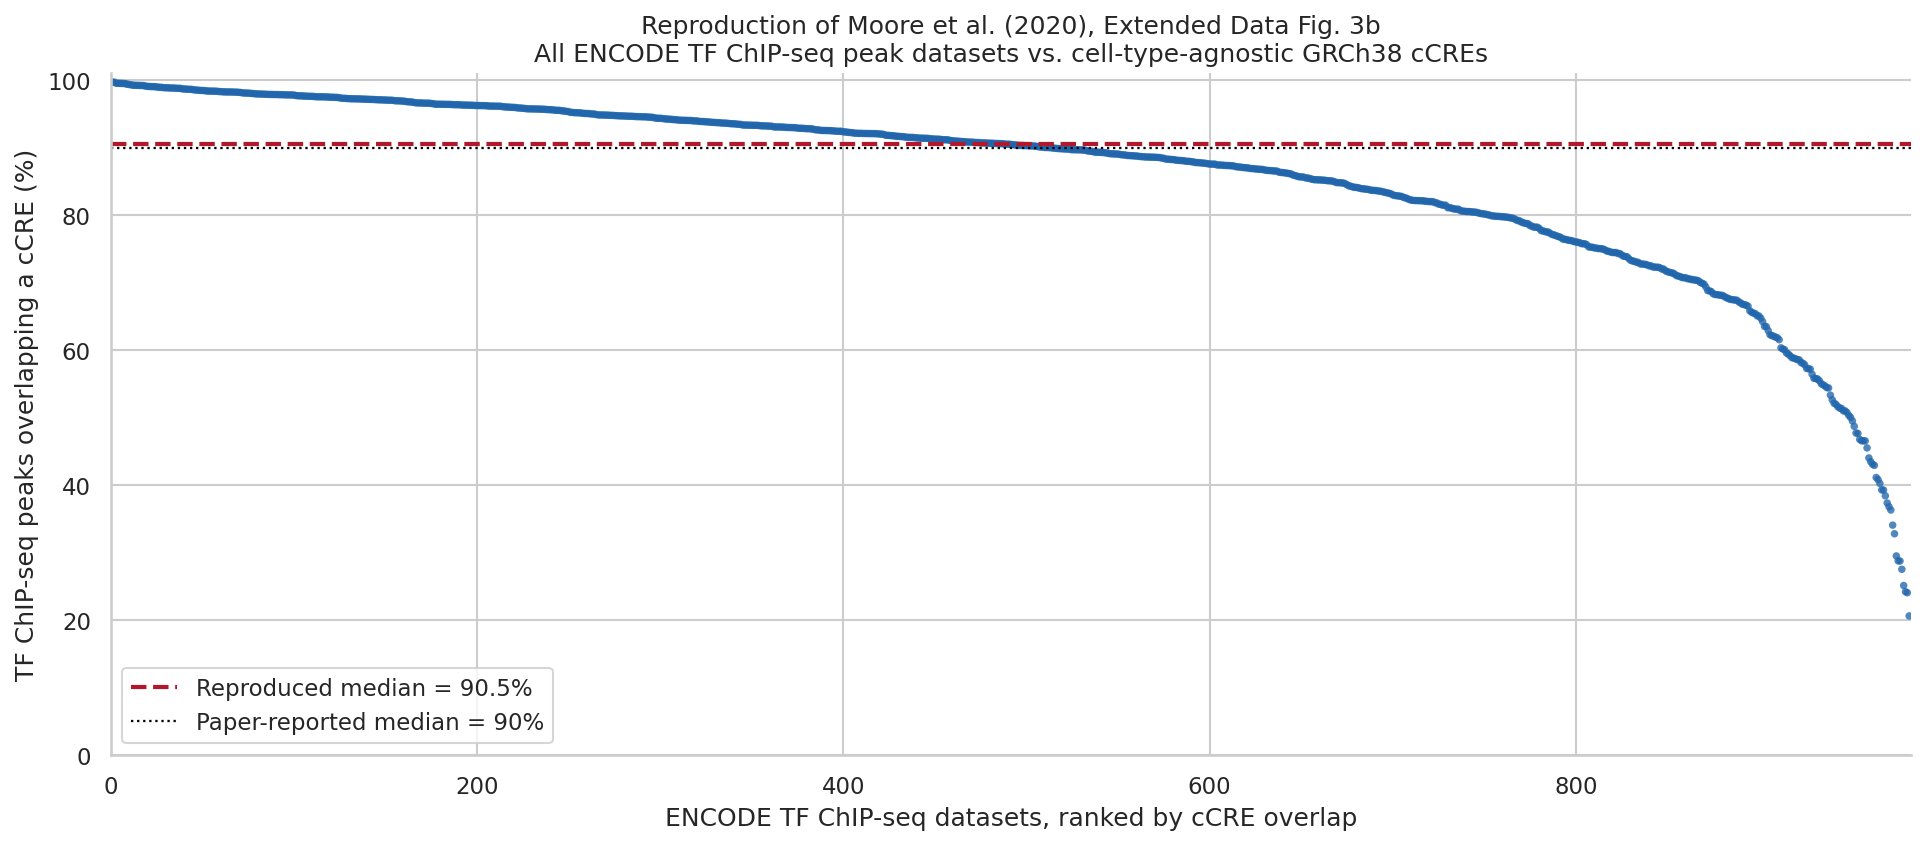

Saved: encode_ccre_extended_data_fig_3b/extended_data_fig_3b_ranked_points.png


In [9]:

# Figure 1: ranked scatter plot of per-dataset overlap percentages

# This reproduces the qualitative shape of Extended Data Fig. 3b: each point
# is one ENCODE TF ChIP-seq dataset, sorted by its cCRE-overlap percentage so
# the resulting scatter forms a smooth descending curve, making it easy to
# see the overall distribution and where the median falls.
sns.set_theme(style="whitegrid", context="notebook")

plot_df = (
    results
    .sort_values("authors_percent_overlap", ascending=False)
    .reset_index(drop=True)
)

n_datasets = len(plot_df)

fig, ax = plt.subplots(figsize=(13, 5.8))

ax.scatter(
    np.arange(1, n_datasets + 1),
    plot_df["authors_percent_overlap"],
    s=13,
    color="#2166AC",
    alpha=0.78,
    edgecolor="none",
    rasterized=True
)

ax.axhline(
    median_overlap,
    color="#B2182B",
    linewidth=2.0,
    linestyle="--",
    label=f"Reproduced median = {median_overlap:.1f}%"
)

ax.axhline(
    paper_reported_median,
    color="black",
    linewidth=1.1,
    linestyle=":",
    label="Paper-reported median = 90%"
)

ax.set(
    xlabel="ENCODE TF ChIP-seq datasets, ranked by cCRE overlap",
    ylabel="TF ChIP-seq peaks overlapping a cCRE (%)",
    title=(
        "Reproduction of Moore et al. (2020), Extended Data Fig. 3b\n"
        "All ENCODE TF ChIP-seq peak datasets vs. cell-type-agnostic GRCh38 cCREs"
    ),
    xlim=(0, n_datasets + 1),
    ylim=(0, 101)
)

ax.legend(loc="lower left", frameon=True)
sns.despine(ax=ax)

ranked_figure_path = OUTDIR / "extended_data_fig_3b_ranked_points.png"

fig.tight_layout()
fig.savefig(ranked_figure_path, bbox_inches="tight")
plt.show()

print(f"Saved: {ranked_figure_path}")

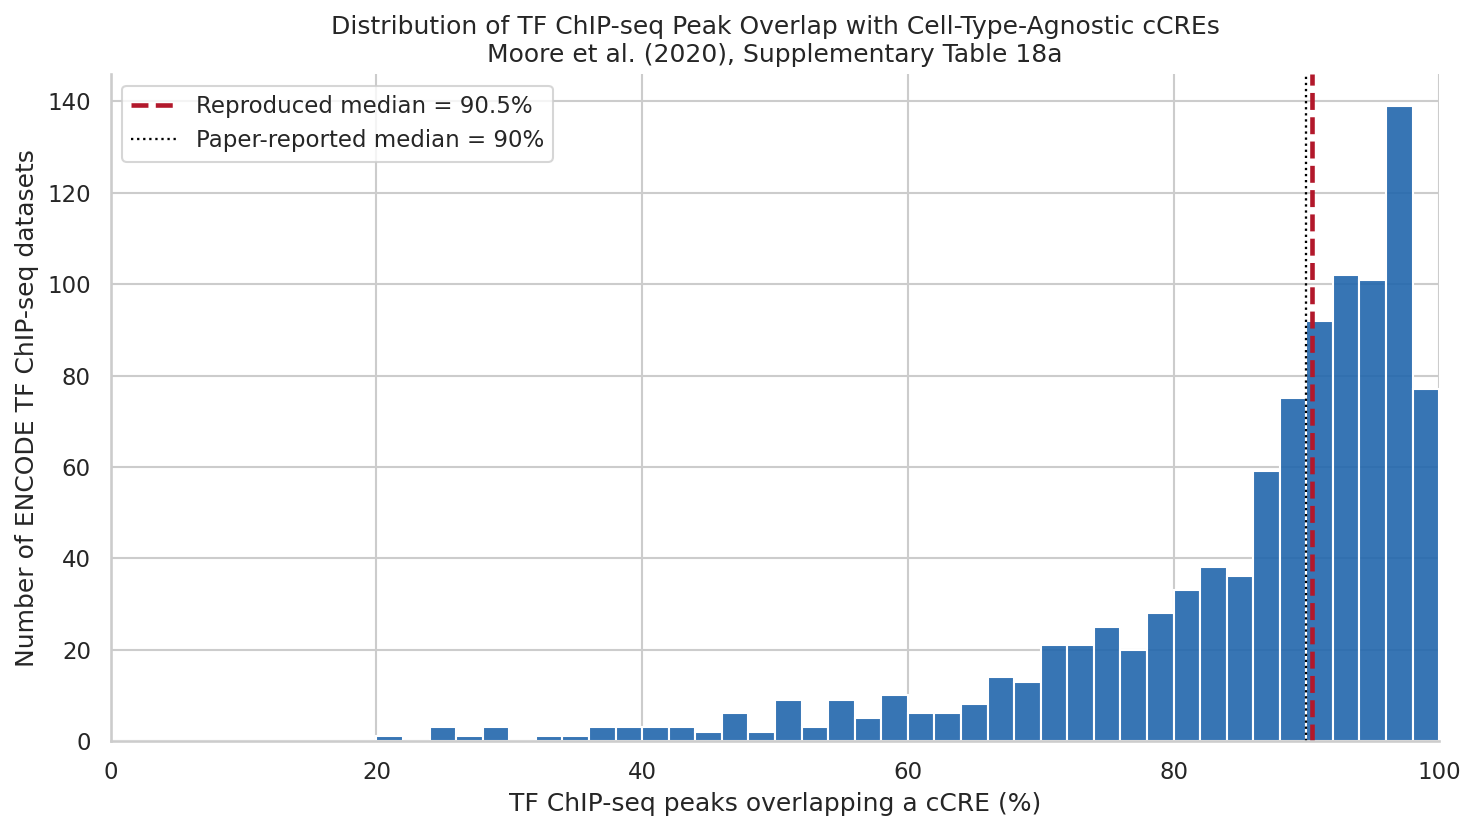

Saved: encode_ccre_extended_data_fig_3b/extended_data_fig_3b_distribution.png


In [10]:

# Figure 2: histogram of overlap percentages

# A complementary view of the same data: instead of showing each dataset
# individually ranked, this bins datasets by overlap percentage to show the
# overall distribution shape (e.g. how skewed it is, where the bulk of
# datasets sit relative to the median).
fig, ax = plt.subplots(figsize=(10, 5.7))

sns.histplot(
    data=results,
    x="authors_percent_overlap",
    binwidth=2,
    binrange=(0, 100),
    color="#2166AC",
    edgecolor="white",
    alpha=0.90,
    ax=ax
)

ax.axvline(
    median_overlap,
    color="#B2182B",
    linewidth=2.2,
    linestyle="--",
    label=f"Reproduced median = {median_overlap:.1f}%"
)

ax.axvline(
    paper_reported_median,
    color="black",
    linewidth=1.1,
    linestyle=":",
    label="Paper-reported median = 90%"
)

ax.set(
    xlabel="TF ChIP-seq peaks overlapping a cCRE (%)",
    ylabel="Number of ENCODE TF ChIP-seq datasets",
    title=(
        "Distribution of TF ChIP-seq Peak Overlap with Cell-Type-Agnostic cCREs\n"
        "Moore et al. (2020), Supplementary Table 18a"
    ),
    xlim=(0, 100)
)

ax.legend(frameon=True)
sns.despine(ax=ax)

distribution_figure_path = OUTDIR / "extended_data_fig_3b_distribution.png"

fig.tight_layout()
fig.savefig(distribution_figure_path, bbox_inches="tight")
plt.show()

print(f"Saved: {distribution_figure_path}")

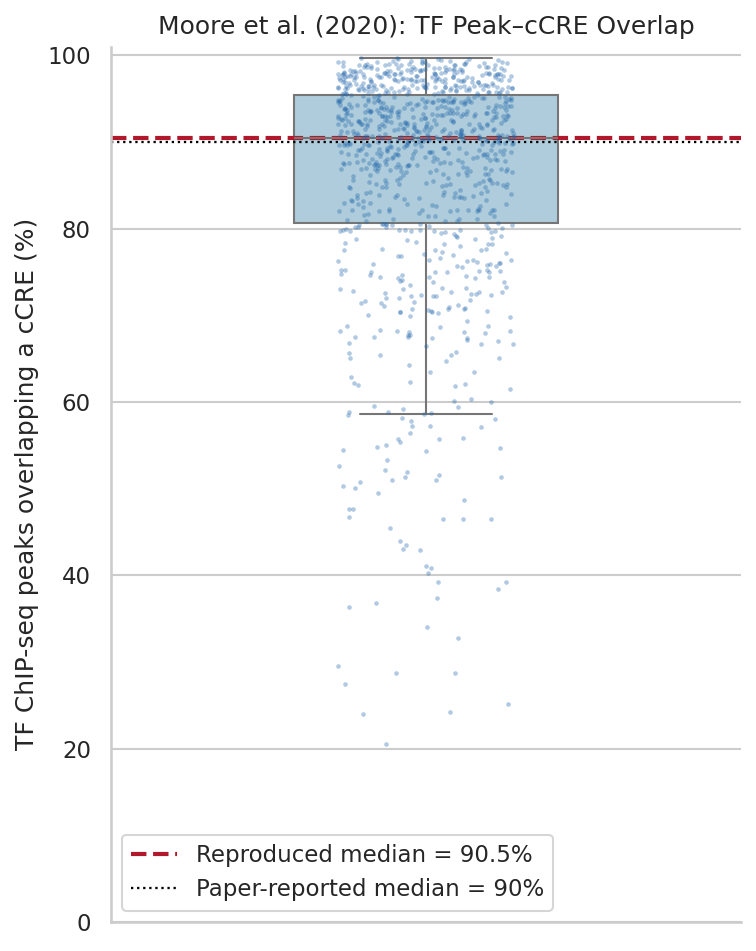

Saved: encode_ccre_extended_data_fig_3b/extended_data_fig_3b_box_strip.png


In [11]:

# Figure 3: box plot + strip plot of overlap percentages

# A third, more compact view of the same distribution: a box plot summarizes
# the quartiles/median, while an overlaid strip plot (jittered individual
# points) shows the actual per-dataset values so no information is hidden by
# the box-plot summary statistics alone.
fig, ax = plt.subplots(figsize=(5.2, 6.5))

sns.boxplot(
    data=results,
    y="authors_percent_overlap",
    color="#A6CEE3",
    width=0.42,
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=results,
    y="authors_percent_overlap",
    color="#2166AC",
    size=2.2,
    alpha=0.35,
    jitter=0.14,
    ax=ax
)

ax.axhline(
    median_overlap,
    color="#B2182B",
    linewidth=2.0,
    linestyle="--",
    label=f"Reproduced median = {median_overlap:.1f}%"
)

ax.axhline(
    paper_reported_median,
    color="black",
    linewidth=1.1,
    linestyle=":",
    label="Paper-reported median = 90%"
)

ax.set(
    xlabel="",
    ylabel="TF ChIP-seq peaks overlapping a cCRE (%)",
    title="Moore et al. (2020): TF Peak–cCRE Overlap"
)

ax.set_xticks([])
ax.set_ylim(0, 101)
ax.legend(loc="lower left", frameon=True)
sns.despine(ax=ax)

boxplot_path = OUTDIR / "extended_data_fig_3b_box_strip.png"

fig.tight_layout()
fig.savefig(boxplot_path, bbox_inches="tight")
plt.show()

print(f"Saved: {boxplot_path}")

In [12]:

# Inspect the low-overlap outlier datasets

# Rather than only summarizing the "below 70% overlap" count (as in the
# summary table above), this pulls out the actual rows for those outlier
# datasets so they can be inspected individually -- e.g. to spot-check
# whether particular biosamples or targets are systematically associated
# with lower cCRE overlap.
low_overlap = (
    results
    .query("authors_percent_overlap < 70")
    .sort_values("authors_percent_overlap", ascending=True)
    .reset_index(drop=True)
)

print(f"Number of datasets below 70% overlap: {len(low_overlap)}")

display(
    low_overlap[
        [
            "experiment_accession",
            "peak_accession",
            "biosample",
            "target",
            "n_peaks",
            "authors_percent_overlap"
        ]
    ]
)

Number of datasets below 70% overlap: 115


,experiment_accession,peak_accession,biosample,target,n_peaks,authors_percent_overlap
0,ENCSR000EUI,ENCFF897HDW,GM08714,ZNF274,918,20.5882
1,ENCSR000EUN,ENCFF239NXT,H1-hESC,ZNF274,1003,24.0279
2,ENCSR000EWY,ENCFF414OZX,NT2/D1,ZNF274,1249,24.1793
3,ENCSR047BUZ,ENCFF737KKO,HepG2,ATF2,40248,25.0969
4,ENCSR370NFS,ENCFF705FAV,K562,ZNF280A,4502,27.4989
...,...,...,...,...,...,...
110,ENCSR000BQD,ENCFF138KWB,T47D,ESR1,2885,68.8042
111,ENCSR065XVO,ENCFF077WVW,K562,CHAMP1,10332,69.3283
112,ENCSR000BTW,ENCFF996MRE,neural cell,POLR2AphosphoS5,47923,69.7431
113,ENCSR000EGQ,ENCFF897LDW,K562,NFYB,8473,69.8926


In [13]:

# Persist the cleaned data and a machine-readable reproduction summary

# Two CSV files are written to OUTDIR as durable, shareable artifacts of this
# reproduction:
#   1. The cleaned per-dataset table (`results`) itself.
#   2. A single-row "metadata" summary describing what was reproduced, from
#      what source, and how the reproduced statistic compares to the
#      originally published one -- useful for provenance/record-keeping.
clean_results_path = OUTDIR / "supplementary_table_18a_cleaned.csv"
summary_path = OUTDIR / "reproduction_summary.csv"

results.to_csv(clean_results_path, index=False)

report_summary = pd.DataFrame([
    {
        "Paper": "ENCODE Project Consortium / Moore et al. (2020)",
        "Target figure": "Extended Data Figure 3b",
        "Original supporting table": "Supplementary Table 18a",
        "Genome assembly": "GRCh38 / hg38",
        "Query interval sets": "ENCODE TF ChIP-seq peak datasets",
        "Target interval set": "Cell-type-agnostic human cCRE registry",
        "cCRE registry size": 926535,
        "Author statistic": (
            "Percentage of TF ChIP-seq peaks overlapping at least one cCRE"
        ),
        "Number of TF ChIP-seq datasets": len(results),
        "Reproduced median overlap (%)": round(median_overlap, 2),
        "Paper-reported median overlap (%)": paper_reported_median,
        "Author table storage format": "Fraction from 0 to 1",
        "Plot storage/analysis format": "Percent from 0 to 100",
        "Original null model": "None; descriptive interval overlap analysis",
        "Baseline reproduction type": (
            "Replotting author-provided per-dataset overlap results"
        )
    }
])

report_summary.to_csv(summary_path, index=False)

print(f"Saved clean data: {clean_results_path}")
print(f"Saved summary: {summary_path}")

display(report_summary.T)

Saved clean data: encode_ccre_extended_data_fig_3b/supplementary_table_18a_cleaned.csv
Saved summary: encode_ccre_extended_data_fig_3b/reproduction_summary.csv


,0
Paper,ENCODE Project Consortium / Moore et al. (2020)
Target figure,Extended Data Figure 3b
Original supporting table,Supplementary Table 18a
Genome assembly,GRCh38 / hg38
Query interval sets,ENCODE TF ChIP-seq peak datasets
Target interval set,Cell-type-agnostic human cCRE registry
cCRE registry size,926535
Author statistic,Percentage of TF ChIP-seq peaks overlapping at...
Number of TF ChIP-seq datasets,982
Reproduced median overlap (%),90.46


In [14]:
from google.colab import files

zip_base = "encode_ccre_extended_data_fig_3b_outputs"
zip_path = shutil.make_archive(zip_base, "zip", OUTDIR)

print(f"Created ZIP archive: {zip_path}")
files.download(zip_path)

Created ZIP archive: /content/encode_ccre_extended_data_fig_3b_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

I reproduced the result showing that most transcription-factor binding peaks detected by ChIP-seq overlap ENCODE’s predicted regulatory DNA regions.

ChIP–seq surveys the interaction between DNA and DNA regulatory proteins such as transcription factors and chromatin remodellers through immunoprecipitation followed by sequencing.